##Step 05 - Latency Profiler (Waterfall Breakdown)

In [ ]:
embed_times    = [r.embed_ms    for r in rag_results]
retrieve_times = [r.retrieve_ms for r in rag_results]
generate_times = [r.generate_ms for r in rag_results]

print(f"Stage averages across {len(TEST_QUESTIONS)} queries:")
total_avg = np.mean([r.total_ms for r in rag_results])
print(f"  Embed:    {np.mean(embed_times):.1f}ms  "
      f"({np.mean(embed_times)/total_avg*100:.1f}% of total)")
print(f"  Retrieve: {np.mean(retrieve_times):.1f}ms  "
      f"({np.mean(retrieve_times)/total_avg*100:.1f}% of total)")
print(f"  Generate: {np.mean(generate_times):.1f}ms  "
      f"({np.mean(generate_times)/total_avg*100:.1f}% of total)")
print(f"  Total:    {total_avg:.1f}ms")

Stage averages across 20 queries:
  Embed:    35.0ms  (1.8% of total)
  Retrieve: 156.9ms  (7.9% of total)
  Generate: 1800.5ms  (90.4% of total)
  Total:    1992.4ms


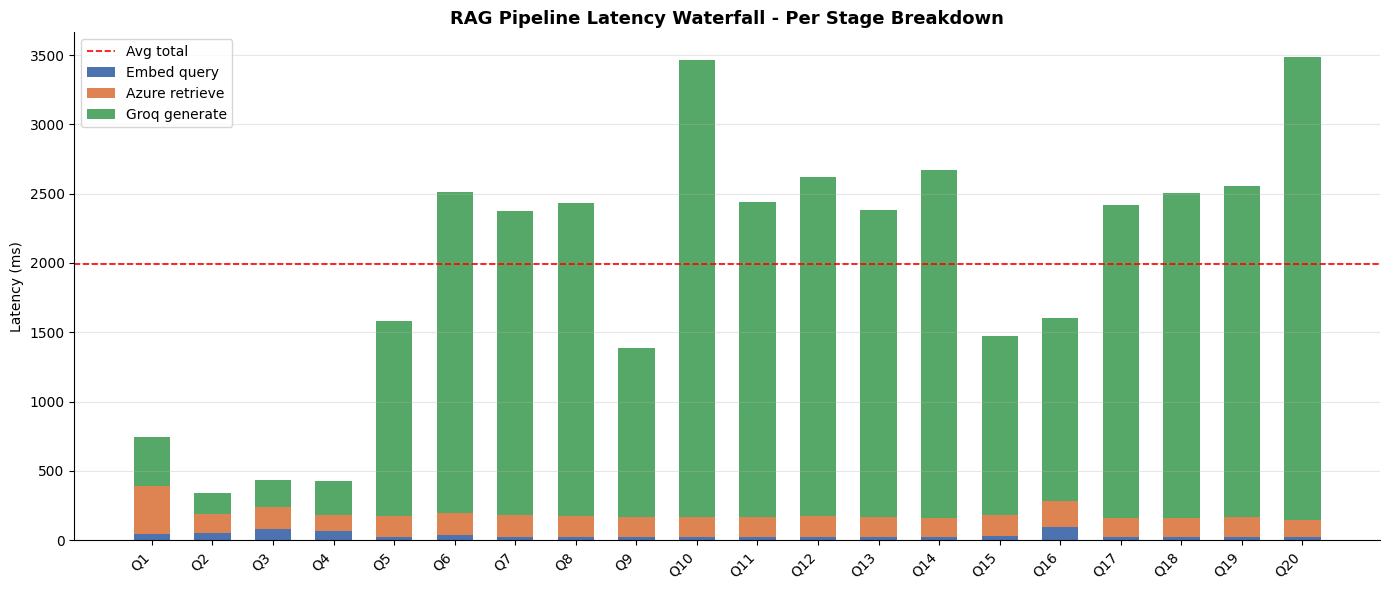

Saved waterfall_breakdown.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(TEST_QUESTIONS))
w = 0.6

ax.bar(x, embed_times,    w, label="Embed query",     color="#4C72B0")
ax.bar(x, retrieve_times, w, bottom=embed_times,
       label="Azure retrieve", color="#DD8452")
ax.bar(x, generate_times, w,
       bottom=[e + r for e, r in zip(embed_times, retrieve_times)],
       label="Groq generate", color="#55A868")

ax.axhline(
    np.mean([e + r + g for e, r, g in zip(embed_times, retrieve_times, generate_times)]),
    color="red", linestyle="--", linewidth=1.2, label="Avg total",
)

ax.set_xticks(x)
ax.set_xticklabels([f"Q{i+1}" for i in range(len(TEST_QUESTIONS))], rotation=45, ha="right")
ax.set_ylabel("Latency (ms)")
ax.set_title("RAG Pipeline Latency Waterfall - Per Stage Breakdown", fontweight="bold", fontsize=13)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("waterfall_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved waterfall_breakdown.png")